# Parameter scans using `web.run`

<img src="img/splitter.png" alt="diagram" width="400"/>

Note: the cost of running the entire notebook is larger than 1 FlexCredit.

In this notebook, we will show an example of using Tidy3D to evaluate device performance over a set of many design parameters.

As of version `2.10`, the [tidy3d.web.run](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.web.api.run.run.html) unifies the submission of a single simulation as well as any nested combination of lists, tuples, and dictionaries of them, handling the same functionality as batch processing with a simpler syntax. As such, it is a natural choice for parameter scans. 

For a guide on how to use the old batch approach, please refer to [this notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/ParameterScan/).

For demonstration, we look at the splitting ratio of a directional coupler as we vary the coupling length between two waveguides. The sidewall of the waveguides is slanted, deviating from the vertical direction by `sidewall_angle`.

In [1]:
# standard python imports
import matplotlib.pyplot as plt
import numpy as np
import photonforge as pf

# Tidy3D imports
import tidy3d as td
from tidy3d import web

11:47:45 -03 WARNING: Using canonical configuration directory at                
             '/home/filipe/.config/tidy3d'. Found legacy directory at           
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

## Setup

First, we set up some global parameters.

In [2]:
# wavelength / frequency
lambda0 = 1.550  # all length scales in microns
freq0 = td.constants.C_0 / lambda0
fwidth = freq0 / 10

# Permittivity of waveguide and substrate
wg_n = 3.48
sub_n = 1.45
mat_wg = td.Medium(permittivity=wg_n**2)
mat_sub = td.Medium(permittivity=sub_n**2)

# Waveguide dimensions

# Waveguide height
wg_height = 0.22
# Waveguide width
wg_width = 0.45
# Waveguide separation in the beginning/end
wg_spacing_in = 8
# Reference plane where the cross section of the device is defined
reference_plane = "bottom"
# Angle of the sidewall deviating from the vertical ones, positive values for the base larger than the top
sidewall_angle = np.pi / 6
# Total device length along propagation direction
device_length = 100
# Length of the bend region
bend_length = 16
# space between waveguide and PML
pml_spacing = 1
# resolution control: minimum number of grid cells per wavelength in each material
grid_cells_per_wvl = 16

### Define waveguide bends and coupler

Here is where we define our directional coupler shape programmatically in terms of the geometric parameters.

For creating the layout we will use [PhotonForge](https://docs.flexcompute.com/projects/photonforge/).

In [3]:
def make_coupler(
    length,
    wg_spacing_in,
    wg_width,
    wg_spacing_coup,
    coup_length,
    bend_length,
):
    """Make an integrated coupler using Photonforge paths."""

    x_start = -0.5 * length
    x_bend_in_start = -0.5 * coup_length - bend_length
    x_coup_start = -0.5 * coup_length
    x_coup_end = 0.5 * coup_length
    x_bend_out_end = 0.5 * coup_length + bend_length
    x_end = 0.5 * length

    y_in = 0.5 * wg_spacing_in
    y_coup = 0.5 * (wg_width + wg_spacing_coup)

    top_path = pf.Path((x_start, y_in), wg_width)
    top_path.segment((x_bend_in_start, y_in))
    top_path.s_bend((x_coup_start, y_coup))
    top_path.segment((x_coup_end, y_coup))
    top_path.s_bend((x_bend_out_end, y_in))
    top_path.segment((x_end, y_in))

    bottom_path = top_path.copy().mirror((1, 0), (0, 0))

    return top_path, bottom_path


### Create Simulation and Submit Job

The following function creates a Tidy3D simulation object for a set of design parameters.

Note that the simulation has not been run yet, just created.

In [4]:
def make_sim(coup_length, wg_spacing_coup, domain_field=True):
    """Make a simulation with a given length of the coupling region and
    distance between the waveguides in that region. If ``domain_field``
    is True, a 2D in-plane field monitor will be added.
    """

    # Build the directional coupler directly with Photonforge paths
    top_path, bottom_path = make_coupler(
        device_length,
        wg_spacing_in,
        wg_width,
        wg_spacing_coup,
        coup_length,
        bend_length,
    )

    coupler1 = td.Structure(
        geometry=td.PolySlab(
            vertices=top_path.to_polygon().vertices,
            axis=2,
            slab_bounds=(0, wg_height),
            sidewall_angle=sidewall_angle,
            reference_plane=reference_plane,
        ),
        medium=mat_wg,
    )

    coupler2 = td.Structure(
        geometry=td.PolySlab(
            vertices=bottom_path.to_polygon().vertices,
            axis=2,
            slab_bounds=(0, wg_height),
            sidewall_angle=sidewall_angle,
            reference_plane=reference_plane,
        ),
        medium=mat_wg,
    )

    substrate = td.Structure(
        geometry=td.Box(
            center=(0, 0, -5),
            size=(device_length, wg_spacing_in + 20, 10),
        ),
        medium=mat_sub,
    )

    # Simulation size along propagation direction
    sim_length = 2 + 2 * bend_length + coup_length

    # Spacing between waveguides and PML
    sim_size = [
        sim_length,
        wg_spacing_in + wg_width + 2 * pml_spacing,
        wg_height + 2 * pml_spacing,
    ]

    # source
    src_pos = -sim_length / 2 + 0.5
    msource = td.ModeSource(
        center=[src_pos, wg_spacing_in / 2, wg_height / 2],
        size=[0, 3, 2],
        source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
        direction="+",
        mode_spec=td.ModeSpec(),
        mode_index=0,
    )

    mon_in = td.ModeMonitor(
        center=[(src_pos + 0.5), wg_spacing_in / 2, wg_height / 2],
        size=[0, 3, 2],
        freqs=[freq0],
        mode_spec=td.ModeSpec(),
        name="in",
    )
    mon_ref_bot = td.ModeMonitor(
        center=[(src_pos + 0.5), -wg_spacing_in / 2, wg_height / 2],
        size=[0, 3, 2],
        freqs=[freq0],
        mode_spec=td.ModeSpec(),
        name="reflect_bottom",
    )
    mon_top = td.ModeMonitor(
        center=[-(src_pos + 0.5), wg_spacing_in / 2, wg_height / 2],
        size=[0, 3, 2],
        freqs=[freq0],
        mode_spec=td.ModeSpec(),
        name="top",
    )
    mon_bot = td.ModeMonitor(
        center=[-(src_pos + 0.5), -wg_spacing_in / 2, wg_height / 2],
        size=[0, 3, 2],
        freqs=[freq0],
        mode_spec=td.ModeSpec(),
        name="bottom",
    )
    monitors = [mon_in, mon_ref_bot, mon_top, mon_bot]

    if domain_field:
        domain_monitor = td.FieldMonitor(
            center=[0, 0, wg_height / 2],
            size=[td.inf, td.inf, 0],
            freqs=[freq0],
            name="field",
        )
        monitors.append(domain_monitor)

    # initialize the simulation
    sim = td.Simulation(
        size=sim_size,
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=grid_cells_per_wvl),
        structures=[substrate, coupler1, coupler2],
        sources=[msource],
        monitors=monitors,
        run_time=50 / fwidth,
        boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    )

    return sim


## Inspect Simulation

Let's create and inspect a single simulation to make sure it was defined correctly before doing the full scan. The sidewalls of the waveguides deviate from the vertical direction by 30 degrees. We also add an in-plane field monitor to have a look at the field evolution in this one simulation. We will not use such a monitor in the batch to avoid storing unnecessarily large amounts of data.

In [5]:
# Length of the coupling region
coup_length = 10

# Waveguide separation in the coupling region
wg_spacing_coup = 0.10

sim = make_sim(coup_length, wg_spacing_coup, domain_field=True)

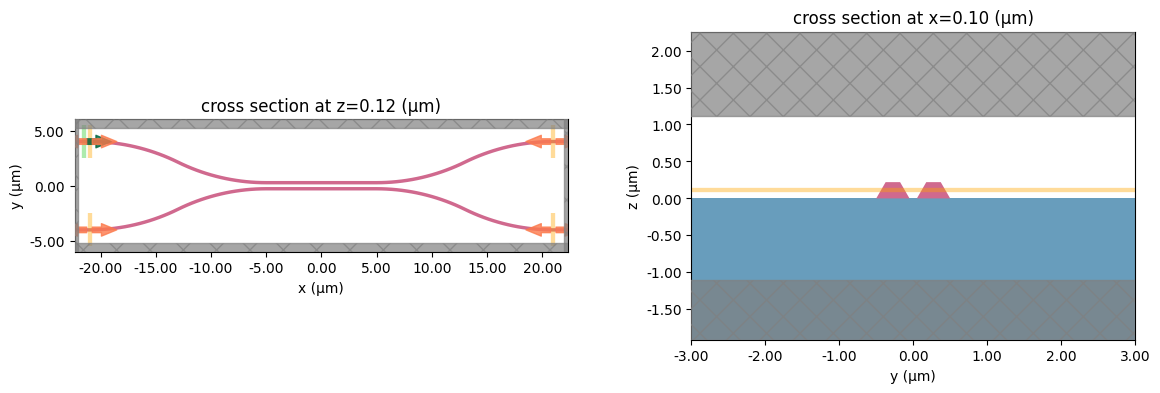

In [6]:
# visualize geometry
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
sim.plot(z=wg_height / 2 + 0.01, ax=ax1)
sim.plot(x=0.1, ax=ax2)
ax2.set_xlim([-3, 3])
plt.show()

## Postprocessing

The following function takes a completed simulation (with data loaded into it) and computes the quantities of interest.

For this case, we measure both the total transmission in the right ports and also the ratio of power between the top and bottom ports.

In [7]:
def measure_transmission(sim_data):
    """Construct a row of the scattering matrix for excitation from the top-left port."""

    input_amp = sim_data["in"].amps.sel(direction="+")

    amps = np.zeros(4, dtype=complex)
    directions = ("-", "-", "+", "+")
    for i, (monitor, direction) in enumerate(zip(sim_data.simulation.monitors[:4], directions)):
        amp = sim_data[monitor.name].amps.sel(direction=direction)
        amp_normalized = amp / input_amp
        amps[i] = np.squeeze(amp_normalized.values)

    return amps

## 1D Parameter Scan

Now we will scan through the coupling length parameter to see the effect on splitting ratio.

To do this, we will create a dictionary of simulations corresponding to each parameter combination.

We will use this dictionary directly with [web.run](https://docs.flexcompute.com/projects/Tidy3D/en/latest/api/_autosummary/Tidy3D.web.api.run.run.html), which can submit and monitor nested combinations of simulations while preserving task names from dictionary keys.

First, we create arrays to store the input and output values.

In [8]:
# create variables to store parameters and results
Nl = 11

ls = np.linspace(5, 12, Nl)


### Create Simulation Set

We now create our dictionary of simulations and submit them with `web.run`.

Using a dictionary is convenient because each key becomes the corresponding task name in the returned mapping.

In [9]:
# submit all jobs
sims = {f"l={l:.2f}": make_sim(l, wg_spacing_coup) for l in ls}

### Monitor Execution

Here `web.run` handles submission, monitoring, and loading of all simulations in one call.

The returned object can be iterated by task name, which is convenient for parameter scans.

In [10]:
batch_results = web.run(sims, verbose=True)

11:47:48 -03 Found all simulations in cache.

11:47:49 -03 WARNING: 11 files have already been downloaded and will be skipped.
             To forcibly overwrite existing files, invoke the load or download  
             function with `replace_existing=True`.                             

### Load and Visualize Results

Finally, we can compute the output quantities and load them into the arrays we created initially.

Then we may plot the results.

First, let's visualize the first simulation.

In [11]:
# Inspect the results of a single run using measure_transmission.

sim_data = batch_results["l=5.00"]

amps_arms = measure_transmission(sim_data)
print("mode amplitudes in each port:\n")
for amp, monitor in zip(amps_arms, sim_data.simulation.monitors[:-1]):
    print(f'\tmonitor     = "{monitor.name}"')
    print(f"\tamplitude^2 = {abs(amp) ** 2:.2f}")
    print(f"\tphase       = {(np.angle(amp)):.2f} (rad)\n")



mode amplitudes in each port:

	monitor     = "in"
	amplitude^2 = 0.00
	phase       = 0.05 (rad)

	monitor     = "reflect_bottom"
	amplitude^2 = 0.00
	phase       = -2.49 (rad)

	monitor     = "top"
	amplitude^2 = 0.05
	phase       = -2.58 (rad)

	monitor     = "bottom"
	amplitude^2 = 0.94
	phase       = 2.13 (rad)



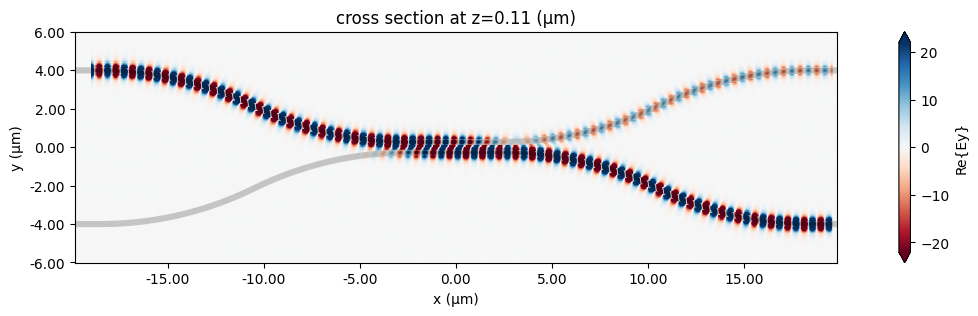

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(16, 3))
sim_data.plot_field("field", "Ey", z=wg_height / 2, f=freq0, ax=ax)
plt.show()

In [13]:
amps_batch = []
for task_name, sim_data in batch_results.items():
    amps_arms_i = np.array(measure_transmission(sim_data))
    amps_batch.append(amps_arms_i)
amps_batch = np.stack(amps_batch, axis=1)
print(amps_batch.shape)  # (4, Nl)
print(amps_batch)

(4, 11)
[[ 7.99843551e-04+3.99957292e-05j -1.42866289e-02+6.46996693e-03j
  -4.51183580e-03+2.05380317e-02j  1.67281370e-04+5.49801574e-03j
  -7.71720772e-03+8.18464896e-03j -7.94741783e-03+1.07711623e-02j
  -2.92663531e-03-2.11822574e-04j -8.79439841e-03-3.69139151e-04j
  -1.87156746e-02+1.74086252e-02j  6.30939352e-03+1.74431757e-02j
  -8.17849742e-03+3.26323497e-04j]
 [-2.71163401e-03-2.06251474e-03j -5.84250535e-03-2.96535613e-03j
  -7.69556497e-03+9.32469846e-03j  5.38861602e-03+4.35465908e-03j
  -4.44536333e-03-6.61358727e-03j -3.35627144e-03+1.08684746e-02j
   2.92978435e-03-7.59187997e-05j -8.18921118e-03-6.45168149e-04j
   5.45285065e-04+6.82588389e-03j -9.39588040e-04+2.86961460e-04j
  -1.34929932e-03-1.93204064e-03j]
 [-1.96378934e-01-1.22227218e-01j -3.07578953e-01+2.15446716e-01j
   1.04675434e-01+4.98908207e-01j  6.15165930e-01+1.30090950e-01j
   4.31602650e-01-5.94623553e-01j -4.09454592e-01-7.15588065e-01j
  -8.94265481e-01+8.82283067e-02j -2.96706729e-01+9.07342022e-01

In [14]:
powers = abs(amps_batch) ** 2
power_top = powers[2]
power_bot = powers[3]
power_out = power_top + power_bot

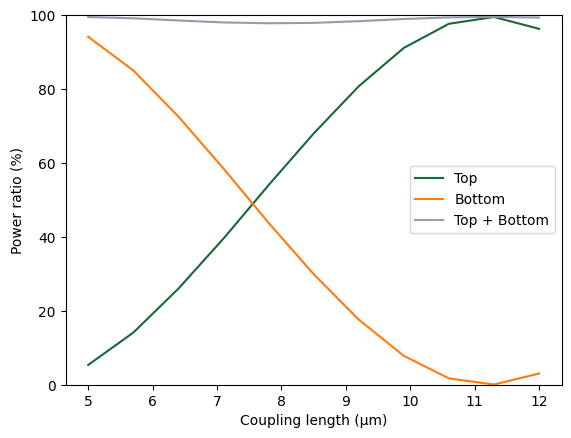

In [15]:
plt.plot(ls, 100 * power_top, label="Top")
plt.plot(ls, 100 * power_bot, label="Bottom")
plt.plot(ls, 100 * power_out, label="Top + Bottom")
plt.xlabel("Coupling length (µm)")
plt.ylabel("Power ratio (%)")
plt.ylim(0, 100)
plt.legend()
plt.show()

## Trying different simulation input structures

`web.run` preserves the same input structure in its output. This means dictionaries, lists, and nested combinations can be used directly to organize parameter scans in a way that matches the physical grouping of the study.

### Example 1: List of Two Dictionaries

Here we group simulations into two dictionaries inside a list. Each dictionary corresponds to one `wg_spacing_coup` value and sweeps five coupling lengths.

In [16]:
list_of_dict_sims = [
    {
        f"spacing_0.10_l={coup_length:.2f}": make_sim(
            coup_length=coup_length,
            wg_spacing_coup=0.10,
            domain_field=False,
        )
        for coup_length in np.linspace(6, 10, 5)
    },
    {
        f"spacing_0.20_l={coup_length:.2f}": make_sim(
            coup_length=coup_length,
            wg_spacing_coup=0.20,
            domain_field=False,
        )
        for coup_length in np.linspace(6, 10, 5)
    },
]

### Run the List of Dictionaries

The output keeps the same outer list and inner dictionary organization, which makes it natural to compare groups defined by waveguide spacing.

In [17]:
list_of_dict_results = web.run(list_of_dict_sims, verbose=True)

11:47:52 -03 Found all simulations in cache.

11:47:53 -03 WARNING: 10 files have already been downloaded and will be skipped.
             To forcibly overwrite existing files, invoke the load or download  
             function with `replace_existing=True`.                             

### Postprocess the List of Dictionaries

We extract the transmission at the top and bottom ports for every simulation while preserving the grouping by `wg_spacing_coup`.

In [18]:
list_of_dict_summary = []

for sim_group in list_of_dict_results:
    group_rows = []
    for task_name, sim_data in sim_group.items():
        amplitudes = np.array(measure_transmission(sim_data))
        powers = np.abs(amplitudes) ** 2
        group_rows.append(
            {
                "task_name": task_name,
                "power_top": powers[2],
                "power_bottom": powers[3],
                "power_total": powers[2] + powers[3],
            }
        )
    list_of_dict_summary.append(group_rows)

list_of_dict_summary

[[{'task_name': 'spacing_0.10_l=6.00',
   'power_top': np.float64(0.18847966744220943),
   'power_bottom': np.float64(0.7999350041214165),
   'power_total': np.float64(0.988414671563626)},
  {'task_name': 'spacing_0.10_l=7.00',
   'power_top': np.float64(0.3754253804852278),
   'power_bottom': np.float64(0.6051169362957538),
   'power_total': np.float64(0.9805423167809816)},
  {'task_name': 'spacing_0.10_l=8.00',
   'power_top': np.float64(0.5800198094102971),
   'power_bottom': np.float64(0.39749783376815334),
   'power_total': np.float64(0.9775176431784505)},
  {'task_name': 'spacing_0.10_l=9.00',
   'power_top': np.float64(0.7734780927255911),
   'power_bottom': np.float64(0.2085840319643226),
   'power_total': np.float64(0.9820621246899137)},
  {'task_name': 'spacing_0.10_l=10.00',
   'power_top': np.float64(0.9226457865356072),
   'power_bottom': np.float64(0.06708511992340382),
   'power_total': np.float64(0.9897309064590111)}],
 [{'task_name': 'spacing_0.20_l=6.00',
   'power_to

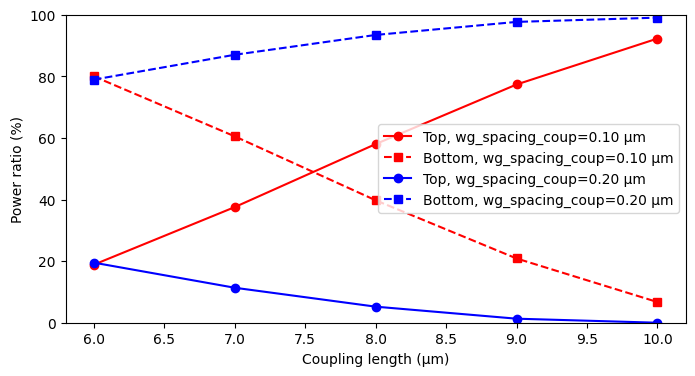

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

color_map = {0.10: "red", 0.20: "blue"}

group_spacings = [0.10, 0.20]
for spacing_value, group_rows in zip(group_spacings, list_of_dict_summary):
    coupling_lengths = [
        float(row["task_name"].split("l=")[-1]) for row in group_rows
    ]
    power_top = [100 * row["power_top"] for row in group_rows]
    power_bottom = [100 * row["power_bottom"] for row in group_rows]

    ax.plot(
        coupling_lengths,
        power_top,
        marker="o",
        label=f"Top, wg_spacing_coup={spacing_value:.2f} µm",
        color=color_map[spacing_value],
    )
    ax.plot(
        coupling_lengths,
        power_bottom,
        marker="s",
        linestyle="--",
        label=f"Bottom, wg_spacing_coup={spacing_value:.2f} µm",
        color=color_map[spacing_value],
    )

ax.set_xlabel("Coupling length (µm)")
ax.set_ylabel("Power ratio (%)")
ax.set_ylim(0, 100)
ax.legend()
plt.show()

### Example 2: Nested List

Here we use a nested list with three inner lists. Each inner list corresponds to one `wg_spacing_coup` value and contains three coupling lengths.

In [20]:
nested_list_spacings = [0.10, 0.15, 0.20]
nested_list_lengths = [
    [6.0, 8.0, 10.0],
    [6.5, 8.5, 10.5],
    [7.0, 9.0, 11.0],
]

nested_list_sims = [
    [
        make_sim(
            coup_length=coup_length,
            wg_spacing_coup=spacing_value,
            domain_field=False,
        )
        for coup_length in coupling_lengths
    ]
    for spacing_value, coupling_lengths in zip(nested_list_spacings, nested_list_lengths)
]

### Run the Nested List

The returned object has the same nested list structure, so indexing follows the original scan layout directly.

In [21]:
nested_list_results = web.run(nested_list_sims, verbose=True)

11:47:54 -03 Found all simulations in cache.

11:47:55 -03 WARNING: 9 files have already been downloaded and will be skipped. 
             To forcibly overwrite existing files, invoke the load or download  
             function with `replace_existing=True`.                             

### Postprocess the Nested List

We compute output powers for each simulation and store them in a nested list that mirrors the simulation input structure.

In [22]:
nested_list_summary = []

for spacing_value, coupling_lengths, sim_group in zip(
    nested_list_spacings, nested_list_lengths, nested_list_results
):
    group_rows = []
    for coup_length, sim_data in zip(coupling_lengths, sim_group):
        amplitudes = np.array(measure_transmission(sim_data))
        powers = np.abs(amplitudes) ** 2
        group_rows.append(
            {
                "wg_spacing_coup": spacing_value,
                "coup_length": coup_length,
                "power_top": powers[2],
                "power_bottom": powers[3],
                "power_total": powers[2] + powers[3],
            }
        )
    nested_list_summary.append(group_rows)

nested_list_summary

[[{'wg_spacing_coup': 0.1,
   'coup_length': 6.0,
   'power_top': np.float64(0.18847966744220943),
   'power_bottom': np.float64(0.7999350041214165),
   'power_total': np.float64(0.988414671563626)},
  {'wg_spacing_coup': 0.1,
   'coup_length': 8.0,
   'power_top': np.float64(0.5800198094102971),
   'power_bottom': np.float64(0.39749783376815334),
   'power_total': np.float64(0.9775176431784505)},
  {'wg_spacing_coup': 0.1,
   'coup_length': 10.0,
   'power_top': np.float64(0.9226457865356072),
   'power_bottom': np.float64(0.06708511992340382),
   'power_total': np.float64(0.9897309064590111)}],
 [{'wg_spacing_coup': 0.15,
   'coup_length': 6.5,
   'power_top': np.float64(3.0477646702818768e-05),
   'power_bottom': np.float64(0.9860769704911146),
   'power_total': np.float64(0.9861074481378175)},
  {'wg_spacing_coup': 0.15,
   'coup_length': 8.5,
   'power_top': np.float64(0.09354663834697113),
   'power_bottom': np.float64(0.8943357830186874),
   'power_total': np.float64(0.987882421

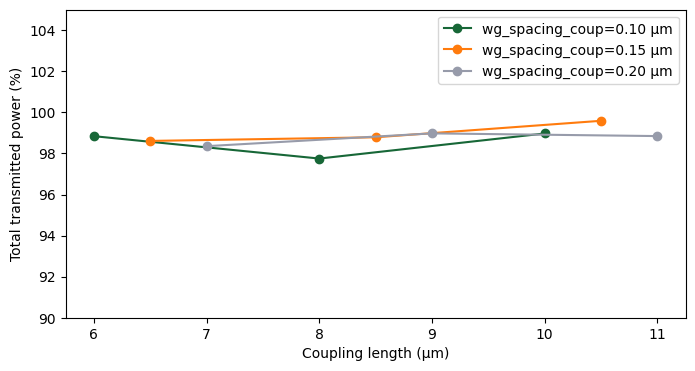

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

for group_rows in nested_list_summary:
    spacing_value = group_rows[0]["wg_spacing_coup"]
    coupling_lengths = [row["coup_length"] for row in group_rows]
    power_total = [100 * row["power_total"] for row in group_rows]

    ax.plot(
        coupling_lengths,
        power_total,
        marker="o",
        label=f"wg_spacing_coup={spacing_value:.2f} µm",
    )

ax.set_xlabel("Coupling length (µm)")
ax.set_ylabel("Total transmitted power (%)")
ax.set_ylim(90, 105)
ax.legend()
plt.show()

### Final Remarks

Using `web.run` keeps the parameter-scan workflow compact because submission, monitoring, and loading are unified in a single call for dictionaries, lists, and tuples of simulations.

This is especially convenient for scripted sweeps where task naming is naturally derived from parameter values.